In [1]:
!pip install xgboost openpyxl

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from xgboost import XGBRegressor, XGBClassifier

In [3]:
train = pd.read_excel("/content/train.xlsx")
test = pd.read_excel("/content/test.xlsx")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/train.xlsx'

In [4]:
from google.colab import files
uploaded = files.upload()

Saving test.xlsx to test.xlsx
Saving train.xlsx to train.xlsx


In [5]:
train = pd.read_excel("/content/train.xlsx")
test = pd.read_excel("/content/test.xlsx")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (20631, 26)
Test shape: (13096, 26)


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Fan inlet temperature,LPC outlet temperature,HPC outlet temperature,LPT outlet temperature,Fan inlet Pressure,...,Ratio of fuel flow to Ps30,Corrected fan speed,Corrected core speed,Bypass Ratio,Burner fuel-air ratio,Bleed Enthalpy,Required fan speed,Required fan conversion speed,High-pressure turbines Cool air flow,Low-pressure turbines Cool air flow
0,1,1,-0.0007,-0.0004,100,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100,39.06,23.4190
1,1,2,0.0019,-0.0003,100,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100,39.00,23.4236
2,1,3,-0.0043,0.0003,100,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100,38.95,23.3442
3,1,4,0.0007,0.0000,100,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100,38.88,23.3739
4,1,5,-0.0019,-0.0002,100,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100,38.90,23.4044


In [6]:
column_names = [
    "unit_number",
    "time_cycle",
    "setting_1",
    "setting_2",
    "setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]

if train.shape[1] == 26:
    train.columns = column_names

if test.shape[1] == 26:
    test.columns = column_names

train.head()

,unit_number,time_cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100,39.06,23.4190
1,1,2,0.0019,-0.0003,100,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100,39.00,23.4236
2,1,3,-0.0043,0.0003,100,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100,38.95,23.3442
3,1,4,0.0007,0.0000,100,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100,38.88,23.3739
4,1,5,-0.0019,-0.0002,100,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100,38.90,23.4044


In [7]:
print("Train eksik veri sayısı:")
print(train.isnull().sum())

print("Test eksik veri sayısı:")
print(test.isnull().sum())

Train eksik veri sayısı:
unit_number    0
time_cycle     0
setting_1      0
setting_2      0
setting_3      0
sensor_1       0
sensor_2       0
sensor_3       0
sensor_4       0
sensor_5       0
sensor_6       0
sensor_7       0
sensor_8       0
sensor_9       0
sensor_10      0
sensor_11      0
sensor_12      0
sensor_13      0
sensor_14      0
sensor_15      0
sensor_16      0
sensor_17      0
sensor_18      0
sensor_19      0
sensor_20      0
sensor_21      0
dtype: int64
Test eksik veri sayısı:
unit_number    0
time_cycle     0
setting_1      0
setting_2      0
setting_3      0
sensor_1       0
sensor_2       0
sensor_3       0
sensor_4       0
sensor_5       0
sensor_6       0
sensor_7       0
sensor_8       0
sensor_9       0
sensor_10      0
sensor_11      0
sensor_12      0
sensor_13      0
sensor_14      0
sensor_15      0
sensor_16      0
sensor_17      0
sensor_18      0
sensor_19      0
sensor_20      0
sensor_21      0
dtype: int64


In [8]:
max_cycle = train.groupby("unit_number")["time_cycle"].max().reset_index()
max_cycle.columns = ["unit_number", "max_cycle"]

train = train.merge(max_cycle, on="unit_number", how="left")
train["RUL"] = train["max_cycle"] - train["time_cycle"]

train = train.drop(columns=["max_cycle"])

train[["unit_number", "time_cycle", "RUL"]].head(10)

,unit_number,time_cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


In [9]:
train["failure_label"] = np.where(train["RUL"] <= 30, 1, 0)

train[["unit_number", "time_cycle", "RUL", "failure_label"]].head()

,unit_number,time_cycle,RUL,failure_label
0,1,1,191,0
1,1,2,190,0
2,1,3,189,0
3,1,4,188,0
4,1,5,187,0


In [10]:
train["failure_label"].value_counts()

,count
failure_label,
0,17531
1,3100


In [11]:
constant_cols = []

for col in train.columns:
    if train[col].nunique() <= 1:
        constant_cols.append(col)

print("Sabit kolonlar:", constant_cols)

Sabit kolonlar: ['setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


In [12]:
train = train.drop(columns=constant_cols)
test = test.drop(columns=[col for col in constant_cols if col in test.columns])

In [13]:
drop_cols_rul = ["RUL", "RUL_capped", "failure_label", "unit_number"]

X_rul = train.drop(columns=[col for col in drop_cols_rul if col in train.columns])
y_rul = train["RUL_capped"]

print(X_rul.shape)
print(y_rul.shape)

KeyError: 'RUL_capped'

In [14]:
RUL_CAP = 125
train["RUL_capped"] = train["RUL"].clip(upper=RUL_CAP)

In [15]:
drop_cols_rul = ["RUL", "RUL_capped", "failure_label", "unit_number"]

X_rul = train.drop(columns=[col for col in drop_cols_rul if col in train.columns])
y_rul = train["RUL_capped"]

print(X_rul.shape)
print(y_rul.shape)

(20631, 18)
(20631,)


In [16]:
unique_units = train["unit_number"].unique()

train_units, val_units = train_test_split(
    unique_units,
    test_size=0.2,
    random_state=42
)

train_data = train[train["unit_number"].isin(train_units)]
val_data = train[train["unit_number"].isin(val_units)]

X_train_rul = train_data.drop(columns=[col for col in drop_cols_rul if col in train_data.columns])
y_train_rul = train_data["RUL_capped"]

X_val_rul = val_data.drop(columns=[col for col in drop_cols_rul if col in val_data.columns])
y_val_rul = val_data["RUL_capped"]

print("X_train:", X_train_rul.shape)
print("X_val:", X_val_rul.shape)

X_train: (16561, 18)
X_val: (4070, 18)


In [17]:
xgb_rul = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_rul.fit(X_train_rul, y_train_rul)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [18]:
y_pred_rul = xgb_rul.predict(X_val_rul)

mae = mean_absolute_error(y_val_rul, y_pred_rul)
rmse = np.sqrt(mean_squared_error(y_val_rul, y_pred_rul))
r2 = r2_score(y_val_rul, y_pred_rul)

print("XGBoost RUL Sonuçları")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

XGBoost RUL Sonuçları
MAE: 10.644869804382324
RMSE: 15.631388342488068
R2: 0.8595904111862183


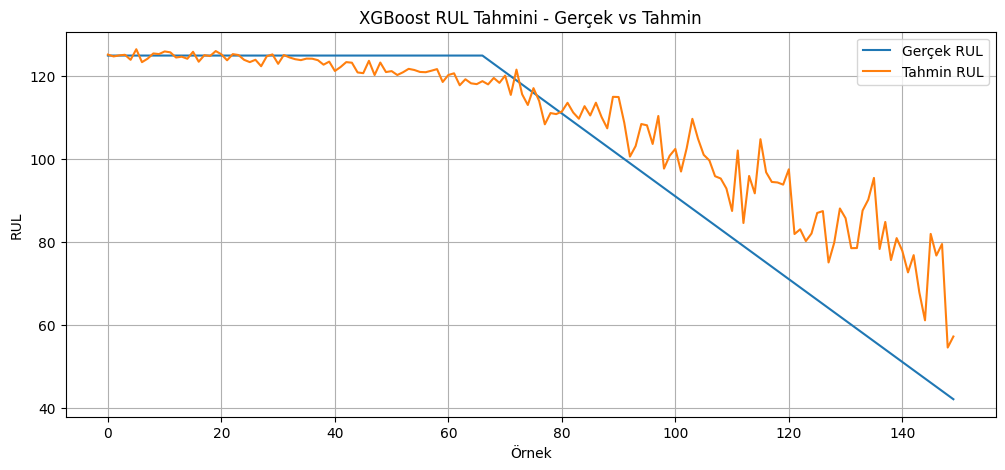

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(y_val_rul.values[:150], label="Gerçek RUL")
plt.plot(y_pred_rul[:150], label="Tahmin RUL")
plt.xlabel("Örnek")
plt.ylabel("RUL")
plt.title("XGBoost RUL Tahmini - Gerçek vs Tahmin")
plt.legend()
plt.grid(True)
plt.show()

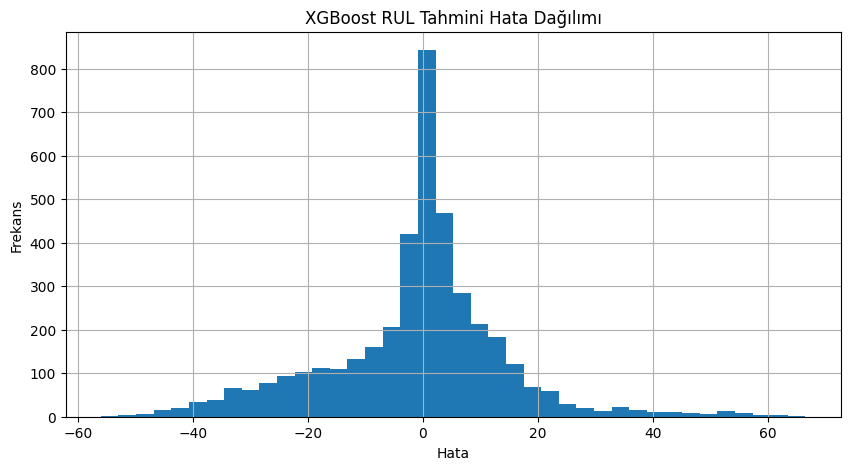

In [20]:
errors = y_val_rul.values - y_pred_rul

plt.figure(figsize=(10, 5))
plt.hist(errors, bins=40)
plt.xlabel("Hata")
plt.ylabel("Frekans")
plt.title("XGBoost RUL Tahmini Hata Dağılımı")
plt.grid(True)
plt.show()

In [21]:
drop_cols_cls = ["RUL", "RUL_capped", "failure_label", "unit_number"]

X_train_cls = train_data.drop(columns=[col for col in drop_cols_cls if col in train_data.columns])
y_train_cls = train_data["failure_label"]

X_val_cls = val_data.drop(columns=[col for col in drop_cols_cls if col in val_data.columns])
y_val_cls = val_data["failure_label"]

In [22]:
xgb_failure = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_failure.fit(X_train_cls, y_train_cls)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [23]:
y_pred_cls = xgb_failure.predict(X_val_cls)
y_prob_cls = xgb_failure.predict_proba(X_val_cls)[:, 1]

acc = accuracy_score(y_val_cls, y_pred_cls)
prec = precision_score(y_val_cls, y_pred_cls)
rec = recall_score(y_val_cls, y_pred_cls)
f1 = f1_score(y_val_cls, y_pred_cls)
auc = roc_auc_score(y_val_cls, y_prob_cls)

print("XGBoost Arıza Olasılığı Sonuçları")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)
print("ROC-AUC:", auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_cls, y_pred_cls))

print("\nClassification Report:")
print(classification_report(y_val_cls, y_pred_cls))

XGBoost Arıza Olasılığı Sonuçları
Accuracy: 0.9638820638820639
Precision: 0.8883415435139573
Recall: 0.8725806451612903
F1-score: 0.8803905614320586
ROC-AUC: 0.9915918653576437

Confusion Matrix:
[[3382   68]
 [  79  541]]

Classification Report:


NameError: name 'classification_report' is not defined

In [24]:
from sklearn.metrics import classification_report

In [25]:
print("\nClassification Report:")
print(classification_report(y_val_cls, y_pred_cls))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3450
           1       0.89      0.87      0.88       620

    accuracy                           0.96      4070
   macro avg       0.93      0.93      0.93      4070
weighted avg       0.96      0.96      0.96      4070



In [26]:
test_last = test.groupby("unit_number").tail(1).copy()

print(test_last.shape)
test_last.head()

(100, 19)


,unit_number,time_cycle,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
30,1,31,-0.0006,0.0004,642.58,1581.22,1398.91,21.61,554.42,2388.08,9056.40,47.23,521.79,2388.06,8130.11,8.4024,393,38.81,23.3552
79,2,49,0.0018,-0.0001,642.55,1586.59,1410.83,21.61,553.52,2388.10,9044.77,47.67,521.74,2388.09,8126.90,8.4505,391,38.81,23.2618
205,3,126,-0.0016,0.0004,642.88,1589.75,1418.89,21.61,552.59,2388.16,9049.26,47.88,520.83,2388.14,8131.46,8.4119,395,38.93,23.2740
311,4,106,0.0012,0.0004,642.78,1594.53,1406.88,21.61,552.64,2388.13,9051.30,47.65,521.88,2388.11,8133.64,8.4634,395,38.58,23.2581
409,5,98,-0.0013,-0.0004,642.27,1589.94,1419.36,21.61,553.29,2388.10,9053.99,47.46,521.00,2388.15,8125.74,8.4362,394,38.75,23.4117


In [27]:
X_test_rul = test_last.copy()

# RUL tahmininde kullanmadığımız kolonları çıkarıyoruz
X_test_rul = X_test_rul.drop(columns=["unit_number"], errors="ignore")

# Eğitimde kullanılan kolon sırasına göre düzenliyoruz
X_test_rul = X_test_rul[X_train_rul.columns]

print(X_test_rul.shape)
X_test_rul.head()

(100, 18)


,time_cycle,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
30,31,-0.0006,0.0004,642.58,1581.22,1398.91,21.61,554.42,2388.08,9056.40,47.23,521.79,2388.06,8130.11,8.4024,393,38.81,23.3552
79,49,0.0018,-0.0001,642.55,1586.59,1410.83,21.61,553.52,2388.10,9044.77,47.67,521.74,2388.09,8126.90,8.4505,391,38.81,23.2618
205,126,-0.0016,0.0004,642.88,1589.75,1418.89,21.61,552.59,2388.16,9049.26,47.88,520.83,2388.14,8131.46,8.4119,395,38.93,23.2740
311,106,0.0012,0.0004,642.78,1594.53,1406.88,21.61,552.64,2388.13,9051.30,47.65,521.88,2388.11,8133.64,8.4634,395,38.58,23.2581
409,98,-0.0013,-0.0004,642.27,1589.94,1419.36,21.61,553.29,2388.10,9053.99,47.46,521.00,2388.15,8125.74,8.4362,394,38.75,23.4117


In [28]:
test_last["predicted_RUL"] = xgb_rul.predict(X_test_rul)

test_last[["unit_number", "time_cycle", "predicted_RUL"]].head(20)

,unit_number,time_cycle,predicted_RUL
30,1,31,123.962143
79,2,49,121.936127
205,3,126,55.756229
311,4,106,84.112564
409,5,98,104.291992
514,6,105,85.781662
674,7,160,108.035179
840,8,166,58.852245
895,9,55,122.275711
1087,10,192,104.870621


In [29]:
X_test_cls = test_last.copy()

# Kullanılmayan kolonları çıkar
X_test_cls = X_test_cls.drop(
    columns=["unit_number", "predicted_RUL"],
    errors="ignore"
)

# Eğitimde kullanılan kolon sırasına göre düzenle
X_test_cls = X_test_cls[X_train_cls.columns]

print(X_test_cls.shape)
X_test_cls.head()

(100, 18)


,time_cycle,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
30,31,-0.0006,0.0004,642.58,1581.22,1398.91,21.61,554.42,2388.08,9056.40,47.23,521.79,2388.06,8130.11,8.4024,393,38.81,23.3552
79,49,0.0018,-0.0001,642.55,1586.59,1410.83,21.61,553.52,2388.10,9044.77,47.67,521.74,2388.09,8126.90,8.4505,391,38.81,23.2618
205,126,-0.0016,0.0004,642.88,1589.75,1418.89,21.61,552.59,2388.16,9049.26,47.88,520.83,2388.14,8131.46,8.4119,395,38.93,23.2740
311,106,0.0012,0.0004,642.78,1594.53,1406.88,21.61,552.64,2388.13,9051.30,47.65,521.88,2388.11,8133.64,8.4634,395,38.58,23.2581
409,98,-0.0013,-0.0004,642.27,1589.94,1419.36,21.61,553.29,2388.10,9053.99,47.46,521.00,2388.15,8125.74,8.4362,394,38.75,23.4117


In [30]:
test_last["failure_probability"] = xgb_failure.predict_proba(X_test_cls)[:, 1]

test_last[["unit_number", "time_cycle", "predicted_RUL", "failure_probability"]].head(20)

,unit_number,time_cycle,predicted_RUL,failure_probability
30,1,31,123.962143,0.000011
79,2,49,121.936127,0.000082
205,3,126,55.756229,0.086651
311,4,106,84.112564,0.003333
409,5,98,104.291992,0.001055
514,6,105,85.781662,0.000241
674,7,160,108.035179,0.000074
840,8,166,58.852245,0.006872
895,9,55,122.275711,0.000343
1087,10,192,104.870621,0.000513


In [31]:
def risk_level(prob, rul):
    if prob >= 0.70 or rul <= 30:
        return "Yüksek Risk"
    elif prob >= 0.40 or rul <= 60:
        return "Orta Risk"
    else:
        return "Düşük Risk"

test_last["risk_level"] = test_last.apply(
    lambda row: risk_level(row["failure_probability"], row["predicted_RUL"]),
    axis=1
)

test_last[["unit_number", "predicted_RUL", "failure_probability", "risk_level"]].head(20)

,unit_number,predicted_RUL,failure_probability,risk_level
30,1,123.962143,0.000011,Düşük Risk
79,2,121.936127,0.000082,Düşük Risk
205,3,55.756229,0.086651,Orta Risk
311,4,84.112564,0.003333,Düşük Risk
409,5,104.291992,0.001055,Düşük Risk
514,6,85.781662,0.000241,Düşük Risk
674,7,108.035179,0.000074,Düşük Risk
840,8,58.852245,0.006872,Orta Risk
895,9,122.275711,0.000343,Düşük Risk
1087,10,104.870621,0.000513,Düşük Risk


In [32]:
def maintenance_recommendation(risk):
    if risk == "Yüksek Risk":
        return "Acil bakım planına alınmalı"
    elif risk == "Orta Risk":
        return "Yakından izlenmeli ve bakım planına dahil edilmeli"
    else:
        return "Normal izleme devam etmeli"

test_last["maintenance_recommendation"] = test_last["risk_level"].apply(maintenance_recommendation)

test_last[[
    "unit_number",
    "time_cycle",
    "predicted_RUL",
    "failure_probability",
    "risk_level",
    "maintenance_recommendation"
]].head(20)

,unit_number,time_cycle,predicted_RUL,failure_probability,risk_level,maintenance_recommendation
30,1,31,123.962143,0.000011,Düşük Risk,Normal izleme devam etmeli
79,2,49,121.936127,0.000082,Düşük Risk,Normal izleme devam etmeli
205,3,126,55.756229,0.086651,Orta Risk,Yakından izlenmeli ve bakım planına dahil edil...
311,4,106,84.112564,0.003333,Düşük Risk,Normal izleme devam etmeli
409,5,98,104.291992,0.001055,Düşük Risk,Normal izleme devam etmeli
514,6,105,85.781662,0.000241,Düşük Risk,Normal izleme devam etmeli
674,7,160,108.035179,0.000074,Düşük Risk,Normal izleme devam etmeli
840,8,166,58.852245,0.006872,Orta Risk,Yakından izlenmeli ve bakım planına dahil edil...
895,9,55,122.275711,0.000343,Düşük Risk,Normal izleme devam etmeli
1087,10,192,104.870621,0.000513,Düşük Risk,Normal izleme devam etmeli


In [33]:
test_last["failure_probability_percent"] = test_last["failure_probability"] * 100

test_last[[
    "unit_number",
    "time_cycle",
    "predicted_RUL",
    "failure_probability_percent",
    "risk_level",
    "maintenance_recommendation"
]].head(20)

,unit_number,time_cycle,predicted_RUL,failure_probability_percent,risk_level,maintenance_recommendation
30,1,31,123.962143,0.001080,Düşük Risk,Normal izleme devam etmeli
79,2,49,121.936127,0.008202,Düşük Risk,Normal izleme devam etmeli
205,3,126,55.756229,8.665116,Orta Risk,Yakından izlenmeli ve bakım planına dahil edil...
311,4,106,84.112564,0.333301,Düşük Risk,Normal izleme devam etmeli
409,5,98,104.291992,0.105538,Düşük Risk,Normal izleme devam etmeli
514,6,105,85.781662,0.024061,Düşük Risk,Normal izleme devam etmeli
674,7,160,108.035179,0.007376,Düşük Risk,Normal izleme devam etmeli
840,8,166,58.852245,0.687198,Orta Risk,Yakından izlenmeli ve bakım planına dahil edil...
895,9,55,122.275711,0.034251,Düşük Risk,Normal izleme devam etmeli
1087,10,192,104.870621,0.051310,Düşük Risk,Normal izleme devam etmeli


In [34]:
final_results = test_last[[
    "unit_number",
    "time_cycle",
    "predicted_RUL",
    "failure_probability_percent",
    "risk_level",
    "maintenance_recommendation"
]].copy()

final_results = final_results.sort_values(by="predicted_RUL")

final_results.head(20)

,unit_number,time_cycle,predicted_RUL,failure_probability_percent,risk_level,maintenance_recommendation
10600,81,213,4.809066,99.920830,Yüksek Risk,Acil bakım planına alınmalı
4465,35,198,5.419356,99.902977,Yüksek Risk,Acil bakım planına alınmalı
4267,34,203,6.551640,99.934631,Yüksek Risk,Acil bakım planına alınmalı
10762,82,162,7.110684,99.837326,Yüksek Risk,Acil bakım planına alınmalı
9919,76,205,12.140310,99.891869,Yüksek Risk,Acil bakım planına alınmalı
8972,68,187,13.036094,98.399239,Yüksek Risk,Acil bakım planına alınmalı
8714,66,147,13.649725,99.722244,Yüksek Risk,Acil bakım planına alınmalı
7205,56,136,14.021358,99.264244,Yüksek Risk,Acil bakım planına alınmalı
6264,49,303,15.621508,79.683388,Yüksek Risk,Acil bakım planına alınmalı
13095,100,198,16.131083,99.762482,Yüksek Risk,Acil bakım planına alınmalı


In [35]:
top_10_risky = final_results.head(10)

top_10_risky

,unit_number,time_cycle,predicted_RUL,failure_probability_percent,risk_level,maintenance_recommendation
10600,81,213,4.809066,99.920830,Yüksek Risk,Acil bakım planına alınmalı
4465,35,198,5.419356,99.902977,Yüksek Risk,Acil bakım planına alınmalı
4267,34,203,6.551640,99.934631,Yüksek Risk,Acil bakım planına alınmalı
10762,82,162,7.110684,99.837326,Yüksek Risk,Acil bakım planına alınmalı
9919,76,205,12.140310,99.891869,Yüksek Risk,Acil bakım planına alınmalı
8972,68,187,13.036094,98.399239,Yüksek Risk,Acil bakım planına alınmalı
8714,66,147,13.649725,99.722244,Yüksek Risk,Acil bakım planına alınmalı
7205,56,136,14.021358,99.264244,Yüksek Risk,Acil bakım planına alınmalı
6264,49,303,15.621508,79.683388,Yüksek Risk,Acil bakım planına alınmalı
13095,100,198,16.131083,99.762482,Yüksek Risk,Acil bakım planına alınmalı


In [36]:
risk_counts = final_results["risk_level"].value_counts()

risk_counts

,count
risk_level,
Düşük Risk,62
Yüksek Risk,19
Orta Risk,19


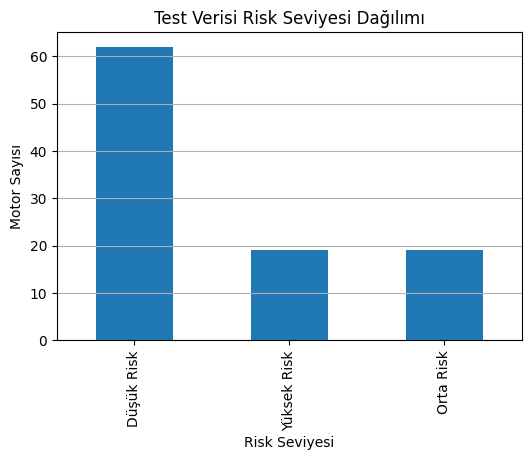

In [37]:
plt.figure(figsize=(6, 4))
risk_counts.plot(kind="bar")
plt.xlabel("Risk Seviyesi")
plt.ylabel("Motor Sayısı")
plt.title("Test Verisi Risk Seviyesi Dağılımı")
plt.grid(axis="y")
plt.show()

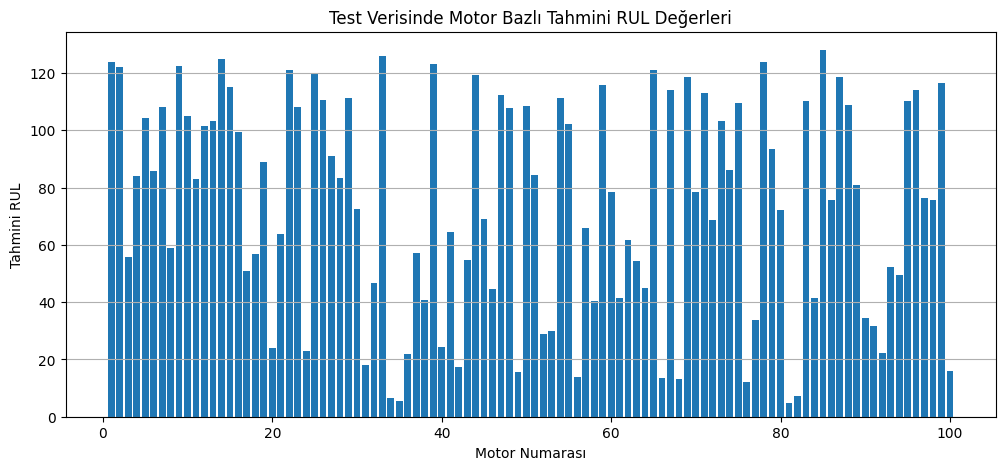

In [38]:
plt.figure(figsize=(12, 5))
plt.bar(final_results["unit_number"], final_results["predicted_RUL"])
plt.xlabel("Motor Numarası")
plt.ylabel("Tahmini RUL")
plt.title("Test Verisinde Motor Bazlı Tahmini RUL Değerleri")
plt.grid(axis="y")
plt.show()

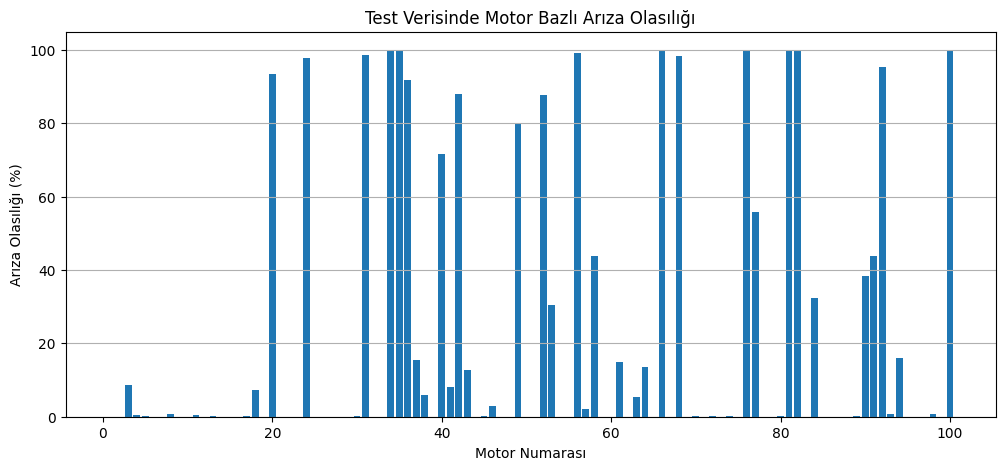

In [39]:
plt.figure(figsize=(12, 5))
plt.bar(final_results["unit_number"], final_results["failure_probability_percent"])
plt.xlabel("Motor Numarası")
plt.ylabel("Arıza Olasılığı (%)")
plt.title("Test Verisinde Motor Bazlı Arıza Olasılığı")
plt.grid(axis="y")
plt.show()

In [40]:
final_results.to_excel("xgboost_test_sonuclari.xlsx", index=False)

print("Sonuç dosyası oluşturuldu: xgboost_test_sonuclari.xlsx")

Sonuç dosyası oluşturuldu: xgboost_test_sonuclari.xlsx


In [41]:
model_performance = pd.DataFrame({
    "Model": ["XGBoost Regressor", "XGBoost Classifier"],
    "Problem": ["RUL Tahmini", "Arıza Olasılığı Tahmini"],
    "MAE": [mae, np.nan],
    "RMSE": [rmse, np.nan],
    "R2": [r2, np.nan],
    "Accuracy": [np.nan, acc],
    "Precision": [np.nan, prec],
    "Recall": [np.nan, rec],
    "F1_score": [np.nan, f1],
    "ROC_AUC": [np.nan, auc]
})

model_performance

,Model,Problem,MAE,RMSE,R2,Accuracy,Precision,Recall,F1_score,ROC_AUC
0,XGBoost Regressor,RUL Tahmini,10.64487,15.631388,0.85959,NaN,NaN,NaN,NaN,NaN
1,XGBoost Classifier,Arıza Olasılığı Tahmini,NaN,NaN,NaN,0.963882,0.888342,0.872581,0.880391,0.991592


In [42]:
model_performance.to_excel("xgboost_model_performans_sonuclari.xlsx", index=False)

print("Model performans dosyası oluşturuldu.")

Model performans dosyası oluşturuldu.


In [43]:
joblib.dump(xgb_rul, "xgb_rul_model.pkl")
joblib.dump(xgb_failure, "xgb_failure_model.pkl")

print("Modeller kaydedildi.")

NameError: name 'joblib' is not defined

In [44]:
import joblib

In [45]:
joblib.dump(xgb_rul, "xgb_rul_model.pkl")
joblib.dump(xgb_failure, "xgb_failure_model.pkl")

print("Modeller kaydedildi.")

Modeller kaydedildi.


In [46]:
joblib.dump(list(X_train_rul.columns), "rul_model_columns.pkl")
joblib.dump(list(X_train_cls.columns), "failure_model_columns.pkl")

print("Model kolonları kaydedildi.")

Model kolonları kaydedildi.


In [47]:
import os
os.listdir("/content")

['.config',
 'test.xlsx',
 'xgb_failure_model.pkl',
 'failure_model_columns.pkl',
 'xgboost_test_sonuclari.xlsx',
 'rul_model_columns.pkl',
 'xgboost_model_performans_sonuclari.xlsx',
 'xgb_rul_model.pkl',
 'train.xlsx',
 'sample_data']

In [48]:
from google.colab import files

download_files = [
    "xgboost_test_sonuclari.xlsx",
    "xgboost_model_performans_sonuclari.xlsx",
    "xgb_rul_model.pkl",
    "xgb_failure_model.pkl",
    "rul_model_columns.pkl",
    "failure_model_columns.pkl"
]

for file_name in download_files:
    files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>